<a href="https://colab.research.google.com/github/Kaveh-Ramezani/202610ELC536501/blob/main/3/FuncAppr_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch + Tanh + Gaussian Mixture Model (GMM)

### 0.  The first imports

In [ ]:
# %tensorflow_version 1.x
import tensorflow as tf
from mpl_toolkits import mplot3d
import numpy as np
import matplotlib.pyplot as plt

### 1. The 2D function to be modeled

In [ ]:
#The 2D function that is to be modeled
def F_mv(x1,x2):
    # return np.sin(np.pi*x1/2.0)*np.cos(np.pi*x2/4.0) # Sinusoidal function
    return np.exp(-x1**2-x2**2) # Gaussian Mixture Model (GMM)
    # return x1**2 - x2**2 # Saddle function

### 2. Activation Functions

In [21]:
def Sigmoid(x):
    return 1/(1 + np.exp(-x))
def ReLU(x):
    return np.maximum(0,x)
def Tanh(x):
    return np.tanh(x)
def ELU(x):
    return np.where(x>0,x,np.exp(x)-1)

ActivationFunction = ReLU

### 3. Visualization of the target function, functions



In [22]:
def visualize_original(Width,Height,U,V):
    H2 = np.empty((Height,Width))
    for i in range(Width):
        u = U * ((i - Width/2.0) / (Width/2.0))
        for j in range(Height):
            v = V *((j - Height/2.0) / (Height/2.0))
            H2[j,i] = F_mv(u,v)  #The 2D func

    return H2

### 4. Visualize combined functions

In [23]:
def visualize_2layer(Width,Height,U,V,W1,b1,W2,b2):
    H2 = np.empty((Height,Width))
    for i in range(Width):
        u = U * ((i - Width/2.0) / (Width/2.0))
        for j in range(Height):
            v = V *((j - Height/2.0) / (Height/2.0))
            x = [u,v]
            h1 = np.vectorize(ActivationFunction)(x*W1+b1)
            h2 = h1 * W2 + b2
            H2[j,i] = h2[0,0]

    return H2

### 5. Generating Training Data

In [24]:
#Generate training data
A = 2
nb_samples = 1000
F = F_mv
X_train = np.random.uniform(-A,A,(nb_samples,2))

Y_train = np.zeros(shape=(nb_samples,1))

for i in range(nb_samples):
    Y_train[i] = [F(X_train[i][0],X_train[i][1])]


### 6. Making the nural network

In [25]:
#Two-Layer Neural Network Structure
N1 = 20  #Number of neurons in the hidden layer

tf.reset_default_graph()
session = tf.InteractiveSession()
# The input layer
with tf.variable_scope("Input"):
    # The input layer with two inputs
    x = tf.placeholder(tf.float32,shape=[None,2])
# The Hidden Layer
with tf.variable_scope("HiddenLayer"):
    # For each neuron we have:
    #   1. Two inputs (From input layer), and
    #   2. N1 outputs (to hidden layer)
    # Each weight
    W1 = tf.Variable(tf.truncated_normal([2,N1],stddev=np.sqrt(6/(2+N1))))
    b1 = tf.Variable(tf.zeros([N1]))
    h1 = tf.nn.relu(tf.add(tf.matmul(x,W1),b1))
# The Output Layer
with tf.variable_scope("OutputLayer"):
    # For each neuron we have:
    #   1. Two inputs (From the Hidden Layer), and
    #   2. N1 outputs (to the output)
    # Each weight
    W2 = tf.Variable(tf.truncated_normal([N1,1],stddev=np.sqrt(6/(N1+1))))
    b2 = tf.Variable(tf.zeros([1]))
    h2 = tf.add(tf.matmul(h1,W2),b2)

with tf.variable_scope("Output"):
    y = tf.placeholder(tf.float32,[None,1])

with tf.variable_scope("Loss"):
    Loss = tf.reduce_sum(tf.square(h2 - y))

### 7. Optimization

In [26]:
#Optimization
eta =(1e-3)
optimizer = tf.train.GradientDescentOptimizer(eta)
optimizer_one_step = optimizer.minimize(Loss)
session.run(tf.global_variables_initializer())

# File_Writer = tf.summary.FileWriter('.\\TwoLayergraph',session.graph)

epochs = int(1e5)
batch_size = 100
epochs_between_two_evaluations = 1e3

for i in range(epochs):
    idx = np.random.permutation(X_train.shape[0])[:batch_size]
    feed_dict = {x:X_train[idx],y:Y_train[idx]}
    optimizer_one_step.run(feed_dict=feed_dict)
    if i % epochs_between_two_evaluations == 0:
        [curr_loss] = session.run([Loss],{x:X_train,y:Y_train})
        print(curr_loss)

1933.7125
10.806555
5.0057635
3.6956406
3.3259068
2.6259274
2.242217
1.9743645
1.6989832
1.5291083
1.5638614
1.3580451
1.3495852
1.2898014
1.2746997
1.6078119
1.3130106
1.2272716
1.2358747
1.1592524
1.1421663
1.0556592
0.9973492
0.99323386
0.94331646
0.9792801
0.93594027
0.9902449
0.9846201
1.0013502
0.89797324
0.91206765
0.9275612
0.91942567
0.90183043
0.90111303
0.93910086
0.8933441
0.9191974
0.9163924
0.88882995
0.85949916
0.94173914
0.99481046
0.89256966
0.87650865
0.8596851
1.0262231
0.9318161
0.86243296
0.8813602
0.863824
0.89893717
0.85791
0.91803133
0.8742965
0.8923054
0.85138327
0.8748388
0.8491509
0.867216
0.83933586
0.8408709
0.8514899
0.9845582
0.83403915
0.8925334
0.92406696
0.83751404
0.82639277
0.86001915
0.83078164
0.826178
0.8489318
0.91550285
0.9279752
0.90306205
0.89728963
1.0840217
0.8334999
0.93205345
0.8192957
0.826768
0.818071
0.82054025
0.83398736
0.91976136
0.87998915
0.80859065
0.82956547
0.82924527
0.8164729
0.8343991
0.84624654
0.8077966
0.8199661
0.87010306

### 8. Visualization

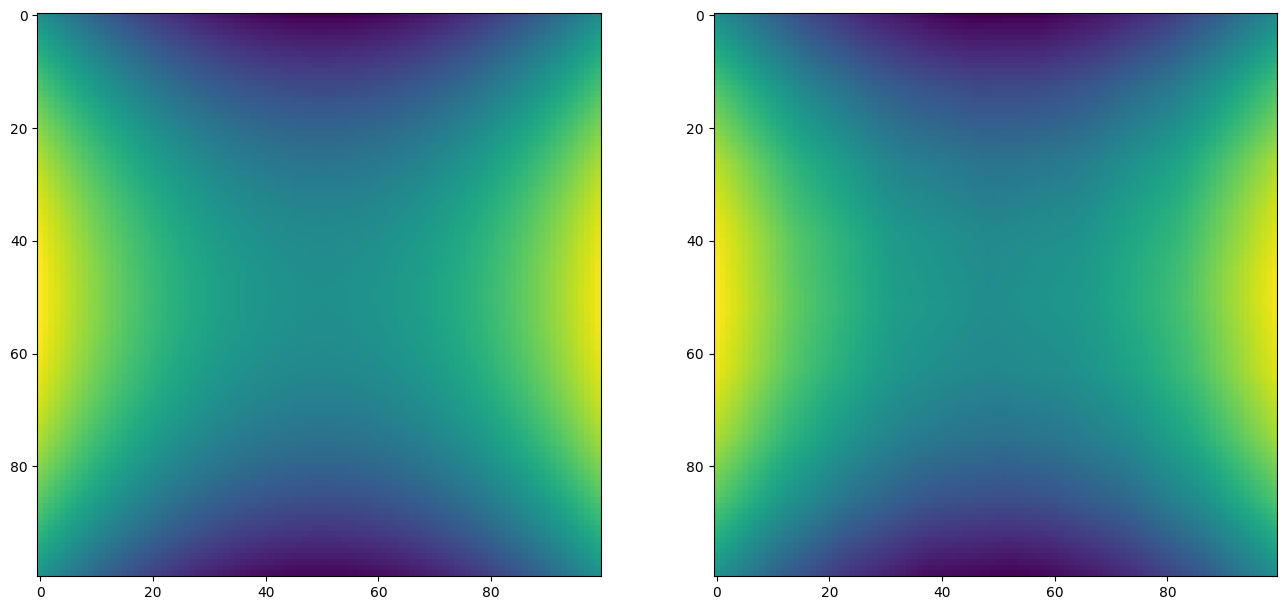

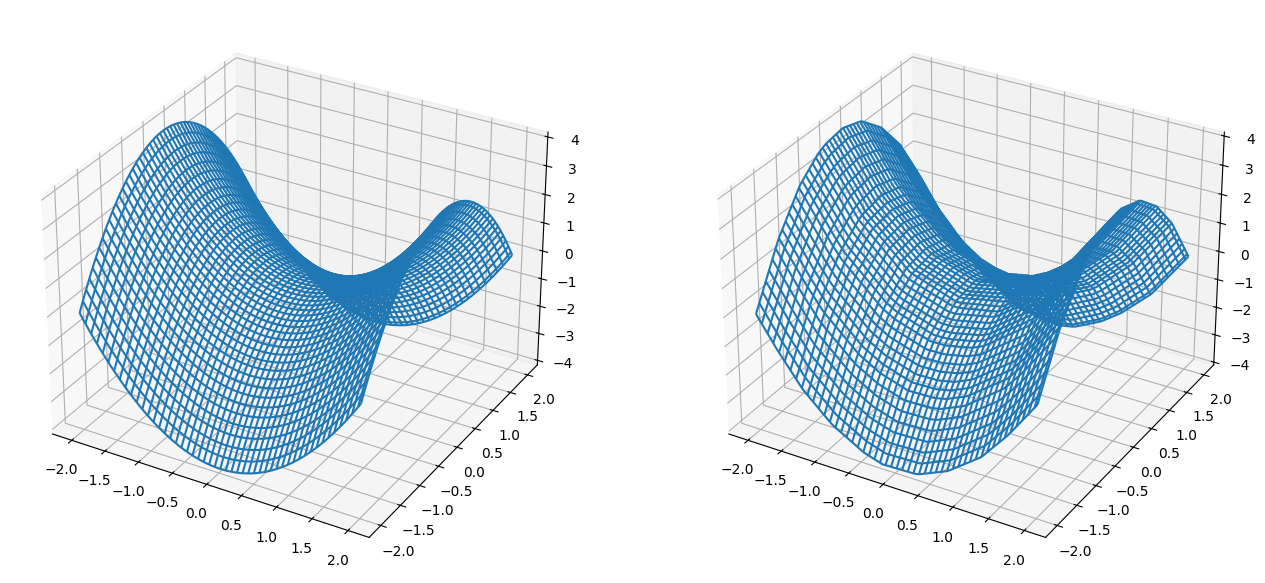

In [27]:
#Visualize the predicted function
[curr_W1,curr_b1,curr_W2,curr_b2,curr_loss] = session.run([W1,b1,W2,b2,Loss],{x:X_train,y:Y_train})

curr_W1 = np.asmatrix(curr_W1)
curr_W2 = np.asmatrix(curr_W2)

I_original = visualize_original(100,100,A,A)

I = visualize_2layer(100,100,A,A,curr_W1,curr_b1,curr_W2,curr_b2)

f = plt.figure(figsize=(16, 8))

f.add_subplot(1,2, 1)
plt.imshow(I_original)
f.add_subplot(1,2, 2)
plt.imshow(I)
#plt.show(block=True)

x = np.linspace(-A, A, 100)
y = np.linspace(-A, A, 100)
X, Y = np.meshgrid(x, y)

fig = plt.figure(figsize=(16, 8))
ax1 = fig.add_subplot(121,projection='3d')
ax1.plot_wireframe(X, Y, I_original)
ax2 = fig.add_subplot(122,projection='3d')
ax2.plot_wireframe(X, Y, I)

session.close()